In [73]:
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
plt.rcParams['font.family'] = 'Helvetica'
import countryinfo as ci
countries = ci.countries
# Define the regions that constitute the Americas
americas_continents = ['North America', 'South America', 'Central America', 'Caribbean']

# Extract unique continents (optional)
unique_continents = set(country['continent'] for country in countries)
print("Unique Continents in Dataset:", unique_continents)

def hpd(data, level): #Thanks Gytis Dudas for this
    """
    Return highest posterior density interval from a list,
    given the percent posterior density interval required.
    """
    d = list(data)
    d.sort()

    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2 :
        return None
    #raise RuntimeError("Not enough data. N data: %s"%(len(data)))
 
    i = 0
    r = d[i+nIn-1] - d[i]
    for k in range(len(d) - (nIn - 1)) :
        rk = d[k+nIn-1] - d[k]
        if rk < r :
            r = rk
            i = k

    assert 0 <= i <= i+nIn-1 < len(d)
 
    return (d[i], d[i+nIn-1])


def basic_formatting( ax, spines=["bottom"], which="y", title=None, ylabel=None, xlabel=None, xsize=12, ysize=12, xlims=None, ylims=None ):
    """
    Specifies the basic formatting of all plots.
    """
    # Remove spines
    [ax.spines[j].set_visible( False ) for j in ax.spines if j not in spines]

    # Format axes ticks
    ax.tick_params( axis="x", bottom=False, which="both", labelbottom=True, labelsize=xsize, pad=0 )
    ax.tick_params( axis="y", left=False, which="both", labelleft=True, labelsize=ysize, pad=0 )

    # Label axes
    ax.set_xlabel( xlabel, fontsize=xsize )
    ax.set_ylabel( ylabel, fontsize=ysize )
    ax.set_title( title )

    ax.set_facecolor( "w" )

    # Add a simple grid
    ax.grid( which="both", axis=which, linewidth=1, color="#F1F1F1", zorder=1 )

    # Add the xlims
    if xlims:
        ax.set_xlim( xlims )
    if ylims:
        ax.set_ylim( ylims )


# Filter countries in the Americas and extract their names
american_countries = [
    country['name'] for country in countries 
    if country['continent'] in americas_continents
]

print("\nCountries in the Americas:")
for name in american_countries:
    print(name)

Unique Continents in Dataset: {'Europe', 'Oceania', 'Asia', 'Africa', 'South America', 'North America'}

Countries in the Americas:
Antigua and Barbuda
Argentina
Barbados
Bolivia
Brazil
Bahamas
Belize
Canada
Chile
Colombia
Costa Rica
Cuba
Dominica
Dominican Republic
Ecuador
Guatemala
Haiti
Guyana
Honduras
Jamaica
Mexico
Nicaragua
Panama
Peru
Paraguay
Suriname
Trinidad and Tobago
United States
Uruguay
Venezuela
El Salvador
Grenada
Saint Kitts and Nevis
Saint Lucia
Saint Vincent and the Grenadines


/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_46081/3506006744.py:12: FutureWarning: The default value of regex will change from True to False in a future version.
  world['name'] = world['name'].str.replace('Bolivia (Plurinational State of)', 'Bolivia')
/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_46081/3506006744.py:13: FutureWarning: The default value of regex will change from True to False in a future version.
  world['name'] = world['name'].str.replace('Venezuela (Bolivarian Republic of)', 'Venezuela')


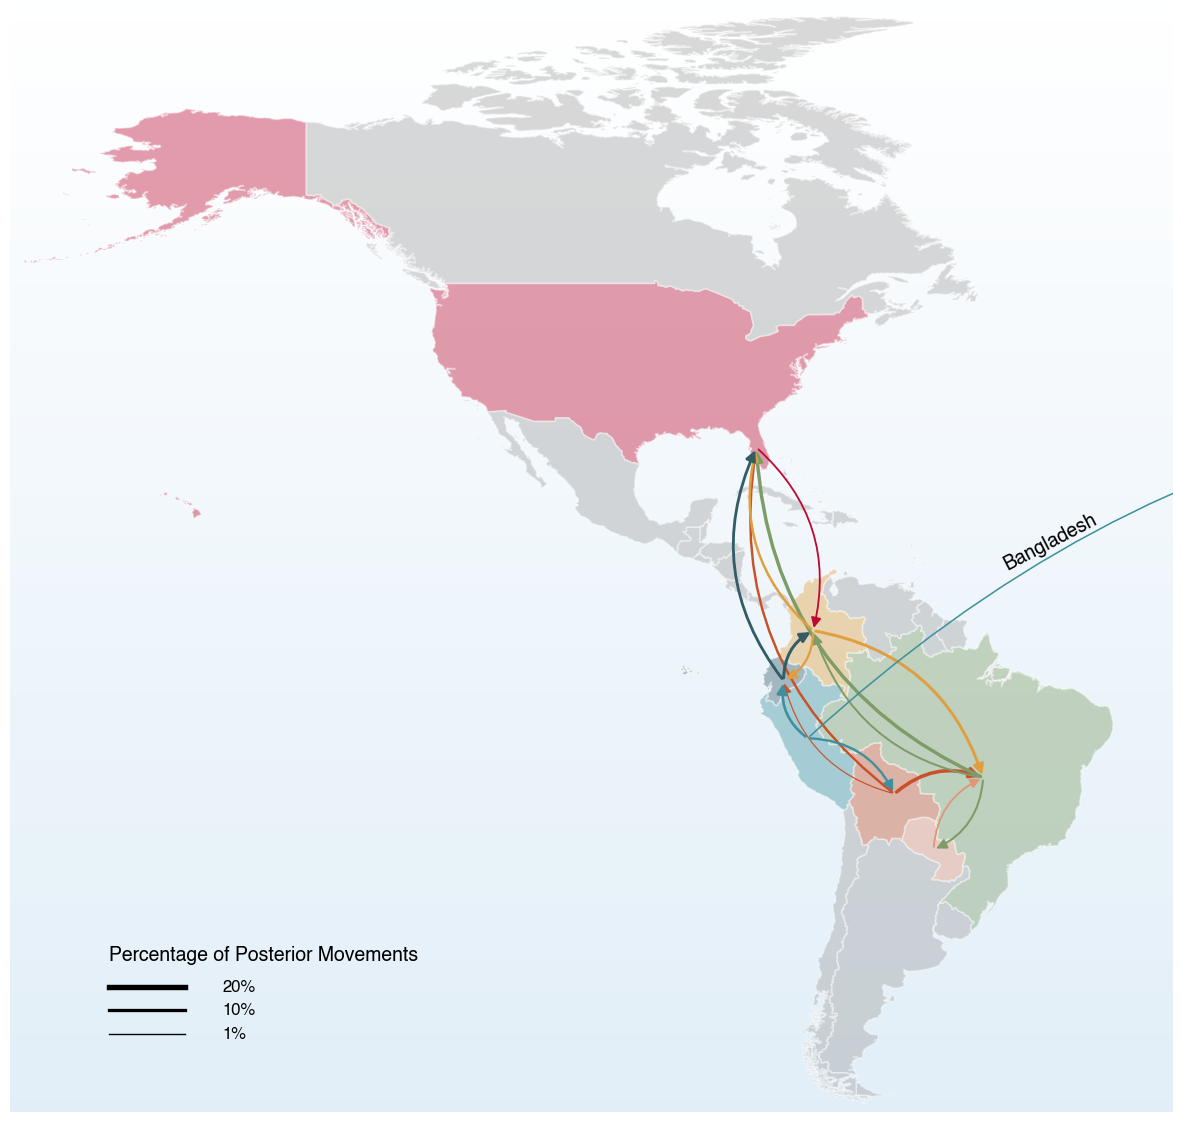

In [53]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import cartopy

# Read the GeoJSON file
world = gpd.read_file('/Users/ricardorivero/Documents/DENV/2024/world-administrative-boundaries.geojson')
world['name'] = world['name'].str.replace('United States of America', 'United States')
world['name'] = world['name'].str.replace('Bolivia (Plurinational State of)', 'Bolivia')
world['name'] = world['name'].str.replace('Venezuela (Bolivarian Republic of)', 'Venezuela')



# Filter for countries in the Americas
America = world[world['name'].isin(american_countries)]

# Define the color palette
palette = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "United States": "#bd0a31",
    "Bangladesh": "#B56A7A"
}

# Define the bounding box coordinates
minx, miny = -180, -57
maxx, maxy = -27, 84

# Create the bounding box
bbox = box(minx, miny, maxx, maxy)

# Convert the bounding box to a GeoDataFrame
bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox]}, crs="EPSG:4326")

# Clip the America GeoDataFrame with the bounding box
America_clipped = gpd.clip(America, bbox_gdf)

# Map colors based on country name
America_clipped['color'] = America_clipped['name'].map(palette)

# Handle countries without a specified color
America_clipped['color'] = America_clipped['color'].fillna('#A0A0A0')

# Define country coordinates (longitude, latitude)
country_coords = {
    "United States": (-81.760254, 	27.994402),
    "Colombia": (-74.2973, 4.5709),
    "Brazil": (-51.9253, -14.2350),
    "Peru": (-75.0152, -9.19),
    "Mexico": (-102.5528, 23.6345),
    "Ecuador": (-78.1834, -1.8312),
    "Bolivia": (-63.5887, -16.2902),
    "Central_America": (-85.2072, 15.7835),
    "Caribbean": (-77.781167, 21.52175),
    "Paraguay": (-58.4438, -23.4425),
    "Bangladesh": (90.3563, 23.6849),
    "Rest_SA" : (-66.916664, 10.500000)
}

# Read connections from CSV
connections_df = pd.read_csv('/Users/ricardorivero/Documents/DENV/2024/D2/F1112/allfiltered_df_F112_summarized.csv')
#Replace USA with United States
connections_df['from'] = filtered_df['from'].str.replace('USA', 'United States')
filtered_df['to'] = connections_df['to'].str.replace('USA', 'United States')

def scale_bayes_factor(x, min_val=1, max_val=20, min_width=3, max_width=350):
    # Normalize x to the [0, 1] range based on the percentage scale (min_val to max_val)
    normalized_x = (x - min_val) / (max_val - min_val)
    
    # Scale the width between min_width and max_width based on the normalized value
    scaled_width = min_width + (normalized_x * (max_width - min_width))
    
    return scaled_width

connections_df['scaled_width'] = connections_df['percentage_movements'].apply(scale_bayes_factor)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.set_facecolor('#e8f1f8')
# Plot the clipped map with the specified colors
#Set function for Alpha
# Define the alpha function based on country membership in american_countries
alpha_func = lambda x: 0.4 if x in american_countries else 1

# Apply the function to the 'name' column and create a new column 'alpha'
America_clipped['alpha'] = America_clipped['name'].apply(alpha_func)

# Plot with varying alpha values

# Generate gradient background
# Define the latitude range (from miny to maxy)
lat_range = np.linspace(miny, maxy, 100)

# Create a 2D array where each row is a color between #e2eff8 and white (along the vertical axis)
colors = np.array([np.linspace(0.886, 1, 100),  # Red channel (from #e2eff8 to white)
                   np.linspace(0.937, 1, 100),  # Green channel (from #e2eff8 to white)
                   np.linspace(0.973, 1, 100)])  # Blue channel (from #e2eff8 to white)

# Convert to 3D array (100x1x3) and transpose it to make the gradient vertical
gradient = np.dstack([colors[0], colors[1], colors[2]])


# Use imshow to plot the gradient background
from scipy import ndimage

rotated_gradient = ndimage.rotate(gradient, -90)
ax.imshow(rotated_gradient, aspect='auto', extent=[minx, maxx, miny, maxy], origin='lower')

America_clipped.plot(ax=ax, color=America_clipped['color'], linewidth=1.2, edgecolor='white', alpha=America_clipped['alpha'])



# Function to draw curved arrows with thin black edges and fill color from origin country
def draw_curved_arrow(ax, start, end, bayes_factor, color, arrowstyle='->', mutation_scale=15):
    # Calculate the midpoint for curvature
    mid_x = (start[0] + end[0]) / 2
    mid_y = (start[1] + end[1]) / 2
    # Adjust the curvature
    delta_x = end[0] - start[0]
    delta_y = end[1] - start[1]
    curvature = -0.3  # Adjust for more or less curvature
    if delta_x == 0 and delta_y == 0:
        curvature = 0
    # Create a FancyArrowPatch with Bezier curve
    arrow = FancyArrowPatch(
        posA=start,
        posB=end,
        connectionstyle=f"arc3,rad={curvature}",
        arrowstyle=arrowstyle,
        facecolor=color,     # Fill color from origin country
        edgecolor=color,       # Thin black edge
        linewidth=np.log10(bayes_factor),         # Thin edge line
        mutation_scale=mutation_scale,
        zorder=5
    )
    ax.add_patch(arrow)

# Iterate through connections and draw arrows
for _, row in connections_df.iterrows():
    from_country = row["from"]
    to_country = row["to"]
    percentage_movements = row["percentage_movements"]
    
    # Get coordinates
    if from_country in country_coords and to_country in country_coords:
        start_lon, start_lat = country_coords[from_country]
        end_lon, end_lat = country_coords[to_country]
        color = palette.get(from_country, 'grey')  # Use the color of the starting country or grey if not found

        scaled_width = row["scaled_width"]
        
        # Draw the curved arrow
        draw_curved_arrow(
            ax,
            start=(start_lon, start_lat),
            end=(end_lon, end_lat),
            bayes_factor=scaled_width,  # Use the bayes.factor from the connection
            color=color,                # Fill color from origin country
            arrowstyle='-|>',           # Arrow style with a filled head
            mutation_scale=15           # Size of the arrow head
        )

start_x, start_y = -75.0152, -9.19  # Coordinates where the arrow starts
end_x, end_y = 90.3563, 23.6849 # Coordinates where the arrow ends

# Calculate the angle of the arrow for the correct text inclination
angle = np.degrees(np.arctan2(end_y - start_y, end_x - start_x))

# Add the text annotation, rotated with the same inclination as the arrow
plt.text(
    (start_x - end_x) / 5-10, (start_y + end_y)*1.1,  # Midpoint of the arrow for text location
    'Bangladesh',  # The text annotation
    fontsize=14,  # Adjust the font size as needed
    rotation=angle*2.45,  # Align the text to the arrow's angle
    ha='center', va='center',  # Center the text at its location
    color='black',  # Text color, adjust if needed
)

# --- Legend ---
# Define percentages and calculate line widths
percentages = [1, 10, 20]
line_widths = [scale_bayes_factor(p, min_val=1, max_val=60, min_width=1, max_width=10) for p in percentages]

# Add legend to the plot
legend_x = maxx - 140
legend_y_start = miny + 10
for i, (perc, width) in enumerate(zip(percentages, line_widths)):
    ax.plot([legend_x, legend_x + 10], [legend_y_start + i * 3, legend_y_start + i * 3], lw=width, color='black')
    ax.text(legend_x + 15, legend_y_start + i * 3, f'{perc}%', fontsize=12, verticalalignment='center')

# Add legend title
ax.text(legend_x, legend_y_start + 10, "Percentage of Posterior Movements", fontsize=14, verticalalignment='center')

# Remove axes
plt.axis('off')

# Center the plot by setting appropriate limits
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Save the plot as high-resolution SVG and JPEG
#plt.savefig('/Users/ricardorivero/Documents/DENV/2024/america_map.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/america_map_F1112_phylogeography.jpeg', format='jpeg', dpi=1200, bbox_inches='tight')
#plt.savefig('/Users/ricardorivero/Documents/DENV/2024/america_map_phylogeography.pdf', format='pdf', dpi=1200, bbox_inches='tight')

# Display the plot
plt.show()

In [142]:
#Violin plot of Markov connections_df from and to Colombia
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#Read the markov connections_df data
def decimal_year_to_date(decimal_year):
    year = int(decimal_year)  # Get the integer part as the year
    remainder = decimal_year - year  # Get the decimal/fractional part
    start_of_year = pd.Timestamp(f'{year}-01-01')  # Start of the year
    # Calculate the date by adding the fractional part as days
    days_in_year = (pd.Timestamp(f'{year + 1}-01-01') - start_of_year).days
    date = start_of_year + pd.to_timedelta(remainder * days_in_year, unit='D')
    return date

mrsd = 2024.62

connections_df = pd.read_csv('/Users/ricardorivero/Documents/DENV/2024/D2/F1112/allJumps_F112.csv')

connections_df['time'] = pd.to_numeric(connections_df['time'], errors='coerce')
connections_df['time'] = mrsd - connections_df['time']
connections_df = connections_df[connections_df['time'] >= 2012]
connections_df['time'] = connections_df['time'].round(2)

# Convert time from decimal year to date
connections_df['time'] = connections_df['time'].apply(decimal_year_to_date)

# Format the date into 'yyyy-mm-dd' format
connections_df['time'] = connections_df['time'].dt.strftime('%Y-%m-%d')

#replace USA with United States
connections_df['from'] = connections_df['from'].str.replace('USA', 'United States')
connections_df['to'] = connections_df['to'].str.replace('USA', 'United States')

# Step 1: Create the "movement" column by concatenating "from" and "to"
connections_df["movement"] = connections_df["from"].str.capitalize() + "To" + connections_df["to"].str.capitalize()

# Step 2: Calculate the total number of movements
total_movements = len(connections_df)

# Step 3: Group by "movement" and count the occurrences
movement_counts = connections_df["movement"].value_counts()

# Step 4: Determine the 1% threshold
threshold = total_movements * 0.01

# Step 5: Filter out movements that are less than 1% of the total movements
valid_movements = movement_counts[movement_counts >= threshold].index
filtered_df = connections_df[connections_df["movement"].isin(valid_movements)].copy()
#Filter for Colombia
filtered_df = filtered_df[filtered_df["movement"].str.contains("Colombia", case=False)]
# Step 6: Check the resulting dataframe
filtered_df.head()



,state,from,to,time,movement
114654,1004000,Brazil,Colombia,2023-01-11,BrazilToColombia
114655,1004000,Brazil,Colombia,2023-12-02,BrazilToColombia
114656,1008000,Brazil,Colombia,2023-12-17,BrazilToColombia
114657,1009000,Brazil,Colombia,2022-09-28,BrazilToColombia
114658,1009000,Brazil,Colombia,2022-10-01,BrazilToColombia


In [162]:
from scipy.signal import savgol_filter
from matplotlib.lines import Line2D
from matplotlib import ticker
from matplotlib.ticker import PercentFormatter

plt.rcParams['font.family'] = 'Helvetica'

def skipped_timeseries_formatting(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    formatter = mdates.DateFormatter('%b')
    long_formatter = mdates.DateFormatter('%b\n%Y')
    accepted_months = ["Jan", "Jun"]
    labels = []
    for date in ax.get_xticks():
        formatted_date = formatter.format_data(date)
        if formatted_date in accepted_months:
            if formatted_date == "Jan":
                labels.append(long_formatter.format_data(date))
            else:
                labels.append(formatted_date)
        else:
            labels.append("")
    ax.set_xticklabels(labels)

palette = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "United States": "#bd0a31",
    "Bangladesh": "#B56A7A"
}
COLOR = '#343434'
# Define mrsd and load data
mrsd = 2024.62

connections_df = pd.read_csv('/Users/ricardorivero/Documents/DENV/2024/D2/F1112/allJumps_F112.csv')

# Convert 'time' to decimal and then to date
connections_df['time'] = pd.to_numeric(connections_df['time'], errors='coerce')
connections_df['time'] = mrsd - connections_df['time']
connections_df = connections_df[connections_df['time'] >= 2012]
connections_df['time'] = connections_df['time'].round(2)
connections_df['time'] = connections_df['time'].apply(decimal_year_to_date)  # Convert to date

# Filter outliers in time
connections_df = connections_df[connections_df['time'] >= pd.Timestamp('2018-01-01')]

# Replace 'USA' with 'United States'
connections_df['from'] = connections_df['from'].str.replace('USA', 'United States')
connections_df['to'] = connections_df['to'].str.replace('USA', 'United States')

# Create the 'movement' column
connections_df["movement"] = connections_df["from"].str.capitalize() + "To" + connections_df["to"].str.capitalize()

# Calculate total number of movements and filter out those less than 1%
total_movements = len(connections_df)
movement_counts = connections_df["movement"].value_counts()
threshold = total_movements * 0.01
valid_movements = movement_counts[movement_counts >= threshold].index
filtered_df = connections_df[connections_df["movement"].isin(valid_movements)].copy()

# Filter for Colombia
jumps = filtered_df[filtered_df["to"] == "Colombia"].copy()
location = "Colombia"

# Create pivot table for plotting
sd_jumps = jumps.loc[(jumps["from"] == location) | (jumps["to"] == location)].copy()
sd_jumps.loc[sd_jumps["to"] == location, "to"] = sd_jumps["from"]
sd_jumps["from"] = location
plot_df = sd_jumps.pivot_table(index="time", columns="to", values="from", aggfunc="count", fill_value=0)
plot_df = plot_df.apply(lambda x: savgol_filter(x, window_length=min(31, len(x)), polyorder=3))
plot_df = plot_df.clip(lower=0)
plot_df = plot_df.apply(lambda x: x / x.sum(), axis=1)
plot_df = plot_df.reindex(columns=sd_jumps["to"].value_counts().sort_values().index)

jumps_mag = sd_jumps.pivot_table(index="time", values="from", aggfunc="count", fill_value=0)
jumps_mag["from"] = savgol_filter(jumps_mag["from"], window_length=min(31, len(jumps_mag)), polyorder=3)
jumps_mag = jumps_mag / jumps_mag.max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 5), dpi=1200, nrows=2, sharex=True,
                       gridspec_kw={"height_ratios": (0.2, 1), "hspace": 0.05})
ax[0].plot(jumps_mag.index, jumps_mag["from"], color=COLOR, zorder=9)
ax[0].fill_between(jumps_mag.index, jumps_mag["from"], color=COLOR, alpha=0.8, zorder=8)

# Handle column types
try:
    plot_df.columns = pd.to_datetime(plot_df.columns).floor('D')
except ValueError:
    pass

# Plot stackplot
ax[1].stackplot(plot_df.index, plot_df.T, labels=plot_df.columns, zorder=9,
                colors=[palette[i] for i in plot_df.columns], alpha=0.7, linewidth=2)

baseline = np.zeros(len(plot_df))
for i in plot_df:
    if i != plot_df.columns[-1]:
        ax[1].plot(plot_df.index, plot_df[i] + baseline, color=COLOR, zorder=10, linewidth=1)
        baseline += plot_df[i]

legend = []
for col in reversed(plot_df.columns):
    legend.append(Line2D([0], [0], linestyle='none', marker='s', color=palette[col] + "7F", markeredgecolor="black", label=col, markersize=12.5))

ax[0].legend(handles=legend, loc="upper center", bbox_to_anchor=(0, 0, 1, 1.55), handletextpad=0.1, frameon=False, fontsize=11, ncol=len(legend))

# Format and display plot
basic_formatting(ax[1], spines=["bottom"], which="both", xlims=(pd.to_datetime("2018-01-01"), pd.to_datetime("2024-09-01")),
                 ylims=(0, 1), ylabel="Percentage of Markov jumps", xsize=12.5, ysize=12.5)
skipped_timeseries_formatting(ax[1])
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax[1].tick_params(axis="y", pad=2.5)

basic_formatting(ax[0], spines=["bottom"], which="both", ylims=(0, 1.05), ylabel="Density", ysize=12.5, xsize=12.5)
skipped_timeseries_formatting(ax[0])
ax[0].set_yticks([0, 1])
ax[0].set_yticklabels([])
ax[0].label_outer()

plt.tight_layout()
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/F1112_MarkovJumps_all.jpeg', format='jpeg', dpi=1200, bbox_inches='tight')
plt.show

/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_40094/3135442911.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels)
/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_40094/3135442911.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<function matplotlib.pyplot.show(close=None, block=None)>